In [1]:
import matplotlib.pyplot as plt


import glob, os
from matplotlib import (pyplot as plt, patches, colors as mplCol)
import numpy as np
import pandas as pd
from astropy.coordinates import (SkyCoord, Distance, Galactic)
from astropy.io import ascii
from astropy import (table, units as u)
from read_mist_models import ISOCMD
from scipy.interpolate import UnivariateSpline
from astroquery.gaia import Gaia

Status messages could not be retrieved


# Load Files Here

In [2]:
path = r'../files/'
full_data = pd.read_csv(path + r'photometric_datav4.csv')
print(full_data.columns.to_list())
print(len(full_data))

gaia_ids = str(list(full_data['Gaia DR3 ID'])).strip('[]')


['star', '2MASS ID', 'Gaia DR3 ID', 'AllWISE ID', 'GALEX ID', 'ra', 'dec', 'distance', 'vsini', 'VSX Period', 'Av', 'fe_h', 'm_G', 'Gaia G flux_over_error', 'm_BP', 'Gaia BP flux_over_error', 'm_RP', 'Gaia RP flux_over_error', '2MASS J', '2MASS J error', '2MASS H', '2MASS H error', '2MASS K', '2MASS K error', 'WISE W1', 'WISE W1 error', 'WISE W2', 'WISE W2 error', 'WISE W3', 'WISE W3 error', 'WISE W4', 'WISE W4 error', 'GALEX FUV', 'GALEX FUV Error', 'GALEX NUV', 'GALEX NUV Error', 'Li Profile', 'H-alpha Profile', 'Ca II H Profile', 'Ca II K Profile', '2MASS_qph', 'ALLWISE_ccf', 'ALLWISE_qph', 'leiner_class', 'updated_class']
1895


In [3]:
full_data_concat = full_data[['star', '2MASS ID', 'Gaia DR3 ID', 'AllWISE ID', 'GALEX ID',
                              'vsini', 'VSX Period', 'Av',
                              '2MASS J', '2MASS J error', '2MASS H', '2MASS H error', 
                              '2MASS K', '2MASS K error', 
                              'WISE W1', 'WISE W1 error', 'WISE W2', 'WISE W2 error', 
                              'WISE W3', 'WISE W3 error', 'WISE W4', 'WISE W4 error', 
                              'GALEX FUV', 'GALEX FUV Error', 'GALEX NUV', 'GALEX NUV Error', 
                              'Li Profile', 'H-alpha Profile', 'Ca II H Profile', 'Ca II K Profile', 
                              '2MASS_qph', 'ALLWISE_ccf', 'ALLWISE_qph', 'leiner_class', 'updated_class']]
full_data_concat = full_data_concat.rename(columns={'Gaia DR3 ID': 'source_id'})
ffull_data_concat = table.Table.from_pandas(full_data_concat)

In [5]:
query_text = f'''SELECT TOP 10000 source_id, ra, dec, bp_rp, 
phot_g_mean_mag, phot_bp_mean_mag,phot_rp_mean_mag,
mh_gspphot, parallax, pmra, pmdec, ruwe,phot_variable_flag, l, b, mh_gspphot_lower, mh_gspphot_upper,
phot_g_mean_flux_over_error, phot_bp_mean_flux_over_error,phot_rp_mean_flux_over_error
FROM gaiadr3.gaia_source 
WHERE gaiadr3.gaia_source.source_id IN ({gaia_ids})'''
job = Gaia.launch_job(query_text) 
gaia_data = job.get_results()

In [6]:
gaia_data = table.join(gaia_data, ffull_data_concat, keys = 'source_id')

In [7]:
gaia_data

source_id,ra,dec,bp_rp,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,mh_gspphot,parallax,pmra,pmdec,ruwe,phot_variable_flag,l,b,mh_gspphot_lower,mh_gspphot_upper,phot_g_mean_flux_over_error,phot_bp_mean_flux_over_error,phot_rp_mean_flux_over_error,star,2MASS ID,AllWISE ID,GALEX ID,vsini,VSX Period,Av,2MASS J,2MASS J error,2MASS H,2MASS H error,2MASS K,2MASS K error,WISE W1,WISE W1 error,WISE W2,WISE W2 error,WISE W3,WISE W3 error,WISE W4,WISE W4 error,GALEX FUV,GALEX FUV Error,GALEX NUV,GALEX NUV Error,Li Profile,H-alpha Profile,Ca II H Profile,Ca II K Profile,2MASS_qph,ALLWISE_ccf,ALLWISE_qph,leiner_class,updated_class
,deg,deg,mag,mag,mag,mag,dex,mas,mas / yr,mas / yr,,,deg,deg,dex,dex,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
int64,float64,float64,float32,float32,float32,float32,float32,float64,float64,float64,float32,object,float64,float64,float32,float32,float32,float32,float32,str28,str22,str25,str22,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str3,str16,str18,str18,str3,str4,str4,str3,str4
18910470421959808,40.65095558618673,7.290585245493459,1.7245846,8.409346,9.2354555,7.510871,--,1.9747769984053039,13.376125652744392,-6.101651756946776,2.3110702,NOT_AVAILABLE,164.96390618428475,-46.310843868755356,--,--,746.51624,193.07515,230.17204,HR Cet,2MASS 02423621+0717260,WISEA J024236.23+071726.0,GALEX J024236.2+071726,--,52.84,0.28,6.244,0.021,5.565,0.047,5.245,0.021,5.004,0.234,4.642,0.135,2.719,0.011,1.669,0.017,19.606800079345703,0.1267,16.569900512695312,0.0176999997347593,--,--,--,--,AAA,0000,BBAA,cut,-999
34148700855166720,43.83780066505116,15.656337721802666,1.4843063,10.65428,11.333716,9.84941,--,1.2561350761478272,5.895475784371175,-8.513067705308604,1.3987987,NOT_AVAILABLE,161.72312805384962,-37.71082957375897,--,--,399.68048,115.44541,278.77017,DG Ari,2MASS 02552105+1539229,WISEA J025521.06+153922.8,GALEX J025521.0+153923,--,34.02,0.31,8.904,0.046,8.22,0.047,8.061,0.018,7.946,0.026,8.015,0.021,7.907,0.022,7.797,0.211,21.556900024414062,0.3671,18.81760025024414,0.0688999965786933,--,--,--,--,AAA,0000,AAAB,RS,-999
54254958891842816,51.01410355127157,15.47253974991323,1.2839956,14.858748,15.42184,14.137844,-0.4777,0.6789366025593843,2.0109631970862374,-2.9367628114152406,0.9188326,VARIABLE,168.53490870847418,-33.56137403732963,-0.5125,-0.4435,266.46628,76.83865,103.00868,CSS J032403.3+152821,2MASS 03240338+1528212,WISEA J032403.38+152821.1,GALEX J032403.3+152821,--,1.07,0.48,13.238,0.022,12.669,0.026,12.534,0.026,12.465,0.024,12.468,0.025,12.21,0.387,8.776,--,--,--,21.83769989013672,0.4056000113487243,--,--,--,--,AAA,0000,AACU,RS,SSG
65719566637012992,58.44664614163716,23.83542417189985,1.2502728,14.168001,14.704685,13.454412,-1.4311,0.8194698250657169,-1.1882176389543933,-4.1642186392025735,0.98975843,VARIABLE,168.01300147540084,-22.671361761139675,-1.5112,-1.2486,708.316,228.09103,237.6548,ZTF J035347.19+235007.6,2MASS 03534721+2350075,WISEA J035347.19+235007.5,--,--,3.88,0.42,12.346,0.021,11.793,0.021,11.658,0.02,11.62,0.024,11.574,0.022,11.368,0.21,8.918,--,--,--,--,--,--,--,--,--,AAA,0000,AABU,RS,SSG
71640436752289408,56.90332442047046,28.10701870991814,1.4130659,15.004778,15.640956,14.22789,-0.3814,0.542836491017919,2.3177327580290603,-1.6493144293201751,1.055705,VARIABLE,163.81272542319238,-20.45450759093475,-0.4576,-0.3077,241.51671,67.421196,87.206116,[WM2007] 85,2MASS 03473679+2806253,WISEA J034736.79+280625.2,GALEX J034736.7+280625,--,2.68,0.37,13.108,0.024,12.483,0.025,12.381,0.025,12.319,0.024,12.285,0.024,12.426,0.528,9.034,--,--,--,21.42569923400879,0.4990000128746032,--,--,--,--,AAA,0000,AACU,RS,SSG
81709523719057536,40.68759334849107,16.305496512913244,1.2449026,14.471627,15.016265,13.771362,-0.5055,0.740113509934223,10.778416626042775,-18.00096982448213,0.9676194,VARIABLE,158.05729755082763,-38.857408287038616,-0.5316,-0.4806,249.56714,77.809166,83.05427,ZTF J024245.02+161819.8,

In [8]:
c = SkyCoord(ra=gaia_data['ra'], dec=gaia_data['dec'], frame='icrs')
ra = c.ra.wrap_at(180 * u.deg).radian
dec = c.dec.radian
metallicity = np.array(gaia_data['mh_gspphot'], dtype = float) #Metallicity

distance = np.array(Distance(parallax=u.Quantity(gaia_data['parallax'])),
                    dtype = float)

m_G = np.array(gaia_data['phot_g_mean_mag'], dtype = float)
uncorr_bp_rp = np.array(gaia_data['bp_rp'], dtype = float)

In [9]:
#Periods
periods = np.array(gaia_data['VSX Period'], dtype=float)
#Reddening
av = np.array(gaia_data['Av'], dtype = float)
ag = av*0.789
Ebp_rp = ag/1.890 #ag/e(bp=rp) = 1.890
bp_rp = uncorr_bp_rp - Ebp_rp
M_G = -5*np.log10(distance) + m_G - ag + 5 #m-M = 5log(d) - 5 + Av

In [10]:
#Compare isocrone for all
#Once you have calculated M_G and BP_RP above,

#highlight stars
HUVir = gaia_data['source_id'] == 3582095053777917952 #HU Vir
FNCom = gaia_data['source_id'] == 3947234928261838720 #FN Com
Dra29 = gaia_data['source_id'] == 1655646778064790528  #29 Dra 
NSVS14892045 = (gaia_data['source_id'] == 3178786251609990656)

#Defining metallicty samples
valid_feh = (metallicity > -9999)

# Metallicity Bins

C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:3710: RuntimeWarning: invalid value encountered in divide
  return sin(y)/y


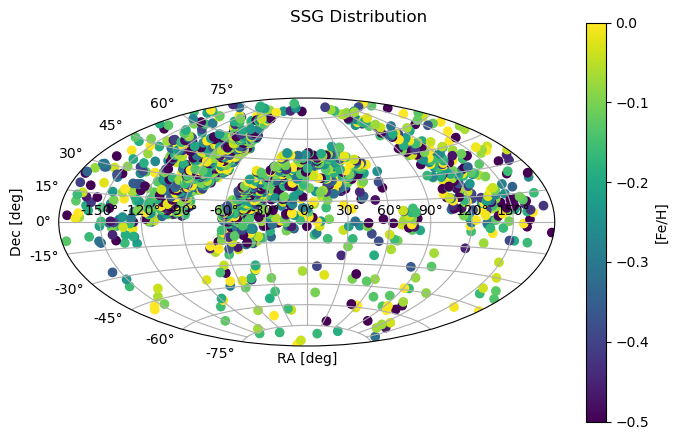

In [11]:
#Test Global Map
fig, ax = plt.subplots(figsize=(8,4.2), 
                       subplot_kw=dict(projection="aitoff"))
fig.suptitle('SSG Distribution')
cs = ax.scatter(ra, dec, c=metallicity, vmax=0, vmin=-0.5)


ax.grid()

cb = fig.colorbar(cs)

cb.set_label('[Fe/H]')
#mpl.cm.set_clim.cb(vmax = 0.25) 
ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')
fig.subplots_adjust(top=0.95,bottom=0.0)

Text(0, 0.5, 'Number of Stars')

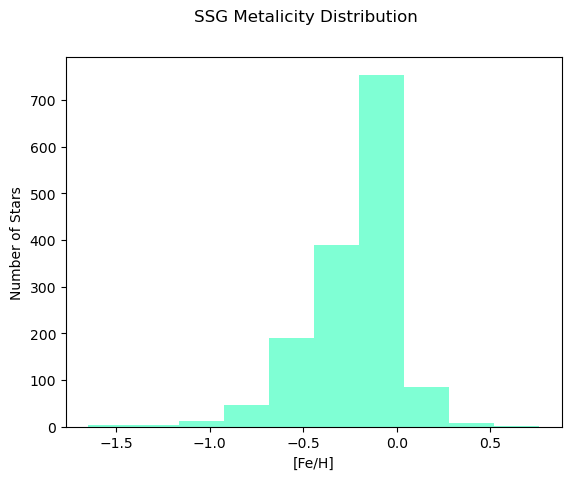

In [12]:
plt.hist(metallicity, color = 'aquamarine')
plt.suptitle('SSG Metalicity Distribution')
plt.xlabel("[Fe/H]")
plt.ylabel("Number of Stars")

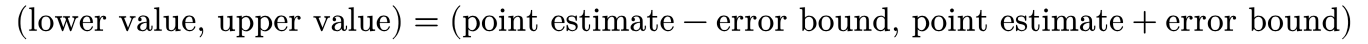

In [13]:
feh_low_error = abs(metallicity - np.array(gaia_data['mh_gspphot_lower']))
feh_up_error = abs(np.array(gaia_data['mh_gspphot_upper']) - metallicity)

In [14]:
print(min(metallicity[metallicity > -999]))
print(len(metallicity[metallicity > 0.5]))

print(np.max(feh_low_error[feh_low_error > -999]))
print(np.max(feh_up_error[feh_low_error > -999]))

bins = np.round(np.arange(-1.7, 0.6,0.1),1)

-1.648800015449524
1
0.9818000197410583
0.4723999798297882


In [15]:
print(bins)

[-1.7 -1.6 -1.5 -1.4 -1.3 -1.2 -1.1 -1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4
 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3  0.4  0.5]


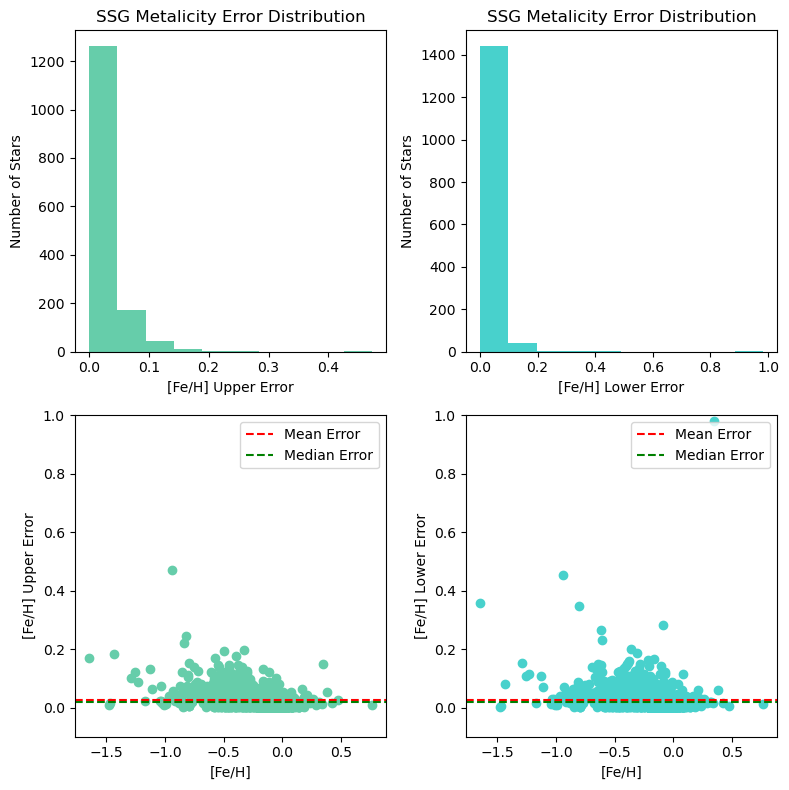

In [16]:
fig, ((ax,ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8,8))
ax.hist(feh_up_error, color = 'mediumaquamarine')
ax.set_title('SSG Metalicity Error Distribution')
ax.set_xlabel("[Fe/H] Upper Error")
ax.set_ylabel("Number of Stars")

ax2.hist(feh_low_error, color = 'mediumturquoise')
ax2.set_title('SSG Metalicity Error Distribution')
ax2.set_xlabel("[Fe/H] Lower Error")
ax2.set_ylabel("Number of Stars")


ax3.scatter(metallicity, feh_up_error, color = 'mediumaquamarine')
ax3.axhline(np.mean(feh_up_error[feh_up_error > -999]), 
            ls = '--', color = 'r', label = 'Mean Error')
ax3.axhline(np.median(feh_up_error[feh_up_error > -999]), 
            ls = '--', color = 'g', label = 'Median Error')
ax3.set_xlabel('[Fe/H]')
ax3.set_ylabel('[Fe/H] Upper Error')
ax3.set_ylim(-0.1,1)
ax3.legend()

ax4.scatter(metallicity, feh_low_error, color='mediumturquoise')
ax4.set_xlabel('[Fe/H]')
ax4.set_ylabel('[Fe/H] Lower Error')

ax4.axhline(np.mean(feh_low_error[feh_low_error > -999]), 
            ls = '--', color = 'r', label = 'Mean Error')
ax4.axhline(np.median(feh_low_error[feh_low_error > -999]), 
            ls = '--', color = 'g', label = 'Median Error')
ax4.legend()
ax4.set_ylim(-0.1,1)

fig.tight_layout()

In [17]:
mean_err = np.mean(feh_up_error[feh_up_error > -999])

#logically of how to do metallicity bins
#err is 0.3
print(mean_err*2)

0.051151271111447905


In [18]:
print(np.log10(14e9))

10.146128035678238


# Isochrones

tool to gather isochrones and EEP tracks: https://waps.cfa.harvard.edu/MIST/ <p>
Isochrones Guides: <br>
&nbsp;&nbsp;&nbsp;&nbsp;get ```read_mist_models.py``` module here: https://github.com/jieunchoi/MIST_codes/blob/master/scripts/read_mist_models.py  <br>
&nbsp;&nbsp;&nbsp;&nbsp;how to use: https://waps.cfa.harvard.edu/MIST/read_mist_models_demo.html <br>
&nbsp;&nbsp;&nbsp;&nbsp;READ ME: https://waps.cfa.harvard.edu/MIST/README_tables.pdf 

In [19]:
def isochrone_opener(iso_file):
    '''
    tool to open isochrones
    '''
    iso_plot = ISOCMD(iso_file)
    G = iso_plot.isocmds[0]['Gaia_G_EDR3']
    BP_RP = iso_plot.isocmds[0]['Gaia_BP_EDR3'] - iso_plot.isocmds[0]['Gaia_RP_EDR3']
    return G, BP_RP, iso_plot

In [24]:
iso_path = '../files/isochrones'
G_05, BP_RP05, iso_plot = isochrone_opener(iso_path + 'MIST_iso_14_gyr_feh_0.5.iso.cmd')
del iso_plt

Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.5.iso.cmd


NameError: name 'iso_plt' is not defined

In [25]:
### # Change this to the path of your folder
iso_path = '../files/isochrones'
file_pattern = os.path.join(r'files/', '*.iso.cmd')  #Retrieve all iso files in the folder
txtfiles = [os.path.basename(file) for file in glob.glob(file_pattern)]  #Extract files into txtfile array
print(txtfiles)

['MIST_iso_14_gyr_feh_0.0.iso.cmd', 'MIST_iso_14_gyr_feh_0.1.iso.cmd', 'MIST_iso_14_gyr_feh_0.2.iso.cmd', 'MIST_iso_14_gyr_feh_0.3.iso.cmd', 'MIST_iso_14_gyr_feh_0.4.iso.cmd', 'MIST_iso_14_gyr_feh_0.5.iso.cmd', 'MIST_iso_14_gyr_feh_low_0.1.iso.cmd', 'MIST_iso_14_gyr_feh_low_0.2.iso.cmd', 'MIST_iso_14_gyr_feh_low_0.3.iso.cmd', 'MIST_iso_14_gyr_feh_low_0.4.iso.cmd', 'MIST_iso_14_gyr_feh_low_0.5.iso.cmd', 'MIST_iso_14_gyr_feh_low_0.6.iso.cmd', 'MIST_iso_14_gyr_feh_low_0.7.iso.cmd', 'MIST_iso_14_gyr_feh_low_0.8.iso.cmd', 'MIST_iso_14_gyr_feh_low_0.9.iso.cmd', 'MIST_iso_14_gyr_feh_low_1.0.iso.cmd', 'MIST_iso_14_gyr_feh_low_1.1.iso.cmd', 'MIST_iso_14_gyr_feh_low_1.2.iso.cmd', 'MIST_iso_14_gyr_feh_low_1.3.iso.cmd', 'MIST_iso_14_gyr_feh_low_1.4.iso.cmd', 'MIST_iso_14_gyr_feh_low_1.5.iso.cmd', 'MIST_iso_14_gyr_feh_low_1.6.iso.cmd']


In [26]:
txtfiles2 = np.array(txtfiles)[np.array([0,3,10])]
print(txtfiles2)

['MIST_iso_14_gyr_feh_0.0.iso.cmd' 'MIST_iso_14_gyr_feh_0.3.iso.cmd'
 'MIST_iso_14_gyr_feh_low_0.5.iso.cmd']


Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.0.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.1.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.2.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.3.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.4.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.5.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.1.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.2.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.3.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.4.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.5.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.6.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.7.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.8.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.9.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_

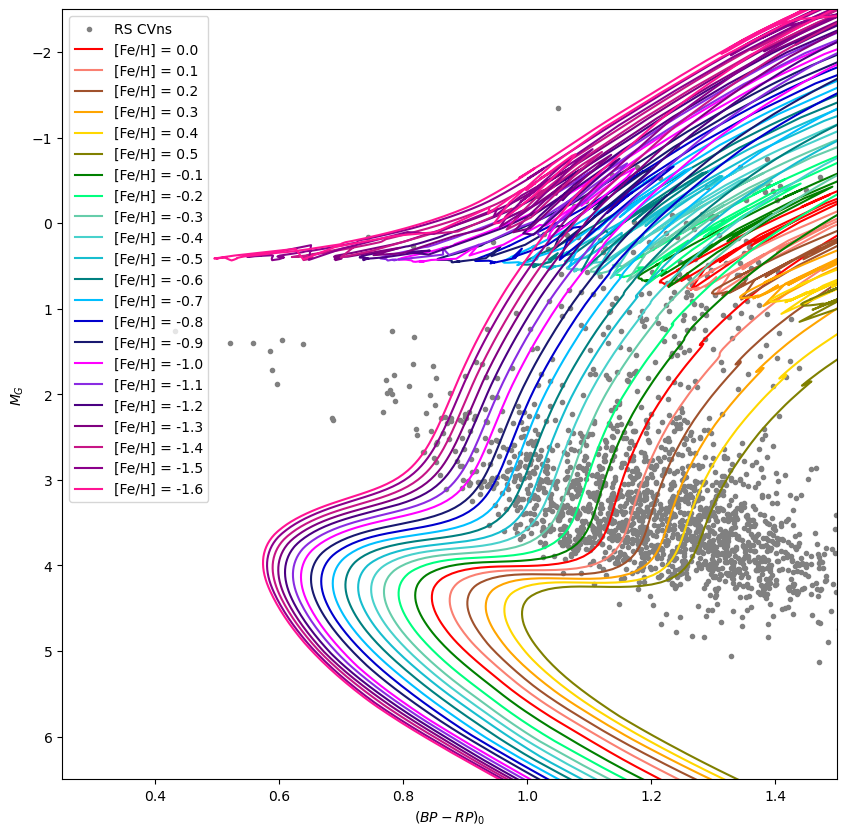

In [27]:
colors = ['red', 'salmon', 'sienna', 'orange', 'gold', 'olive', 'green', 'springgreen', 'mediumaquamarine', 'mediumturquoise',
 'tab:cyan', 'teal', 'deepskyblue', 'mediumblue', 'midnightblue', 'magenta', 'blueviolet', 'indigo', 'purple', 
 'mediumvioletred','darkmagenta', 'deeppink']


fig, ax = plt.subplots(1, figsize=(10,10))
ax.scatter(bp_rp, M_G, marker='.', 
            c = 'grey', label = 'RS CVns', zorder=-10)
    #cb = plt.colorbar(cm, ax=ax)
ax.set_xlim(0.25,1.5)
ax.set_ylim(-2.5,6.5)
ax.invert_yaxis()
ax.set_xlabel('$(BP-RP)_0$')
ax.set_ylabel('$M_G$')


def iso_plt(iso_file, ax, color='black'):
    iso_plot = ISOCMD(iso_file)
    G = iso_plot.isocmds[0]['Gaia_G_EDR3']
    BP_RP = iso_plot.isocmds[0]['Gaia_BP_EDR3'] - iso_plot.isocmds[0]['Gaia_RP_EDR3']
    
    
    feh = iso_file[37:-8]
    if feh[0:3] == 'low':
        feh = '-' + feh[4::]
    feh = float(feh)
    
    ax.plot(BP_RP, G, color = color, label=f'[Fe/H] = {feh}')

for i, txtfile in enumerate(txtfiles):
    iso_plt(iso_path  + txtfile, ax=ax, color=colors[i])
del txtfile

ax.legend()

# Find SSG Fraction

Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.0.iso.cmd
0.0 -0.1
Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.1.iso.cmd
0.1 0.0
Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.2.iso.cmd
0.2 0.1
Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.3.iso.cmd
0.3 0.19999999999999998


C:\Users\astro\AppData\Local\Temp\ipykernel_6296\2888224400.py:72: RankWarning: Polyfit may be poorly conditioned
  g_poly2 = np.polyfit(G[fit_lim][0:max_feh], BP_RP[fit_lim][0:max_feh], 20)


Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.4.iso.cmd
0.4 0.30000000000000004


C:\Users\astro\AppData\Local\Temp\ipykernel_6296\2888224400.py:70: RankWarning: Polyfit may be poorly conditioned
  g_poly1 = np.polyfit(G[min_feh:max_feh], BP_RP[min_feh:max_feh], 20)
C:\Users\astro\AppData\Local\Temp\ipykernel_6296\2888224400.py:72: RankWarning: Polyfit may be poorly conditioned
  g_poly2 = np.polyfit(G[fit_lim][0:max_feh], BP_RP[fit_lim][0:max_feh], 20)


Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.5.iso.cmd


...

Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.1.iso.cmd
-0.1 -0.2
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.2.iso.cmd
-0.2 -0.30000000000000004
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.3.iso.cmd
-0.3 -0.4
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.4.iso.cmd
-0.4 -0.5
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.5.iso.cmd
-0.5 -0.6
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.6.iso.cmd
-0.6 -0.7
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.7.iso.cmd
-0.7 -0.7999999999999999
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.8.iso.cmd
-0.8 -0.9
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.9.iso.cmd
-0.9 -1.0
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_1.0.iso.cmd
-1.0 -1.1
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_1.1.iso.cmd
-1.1 -1.2000000000000002
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_1.2.iso.cmd
-1.2 -1.3
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_1

C:\Users\astro\AppData\Local\Temp\ipykernel_6296\2888224400.py:60: RankWarning: Polyfit may be poorly conditioned
  g_poly1 = np.polyfit(G[0:max_feh], BP_RP[0:max_feh], 20)


Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_1.5.iso.cmd
-1.5 -1.6


C:\Users\astro\AppData\Local\Temp\ipykernel_6296\2888224400.py:90: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax, ax2) = plt.subplots(1,2, figsize=(10,5))


Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_1.6.iso.cmd
-1.6 -1.7000000000000002


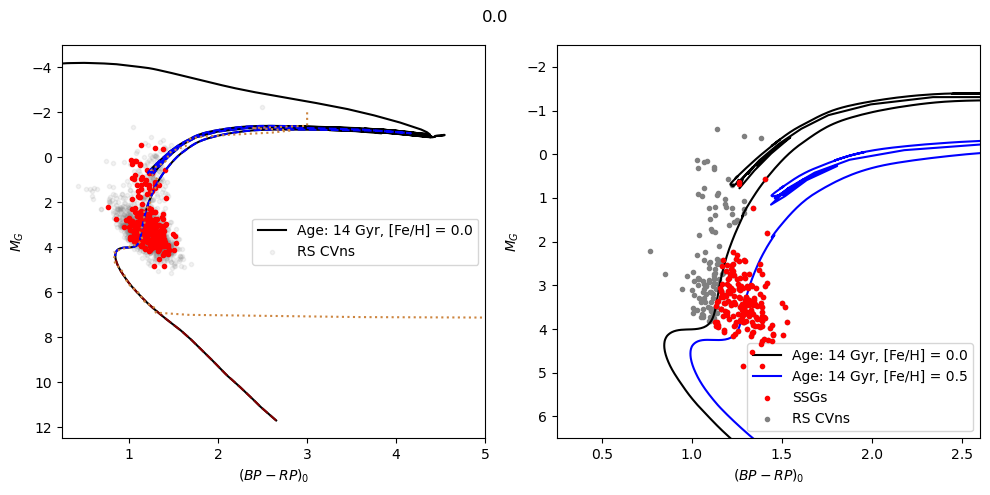

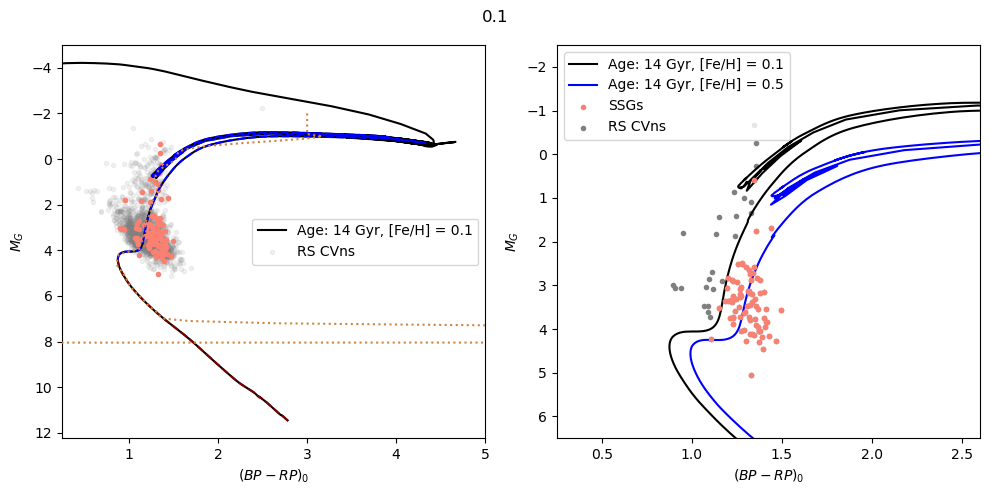

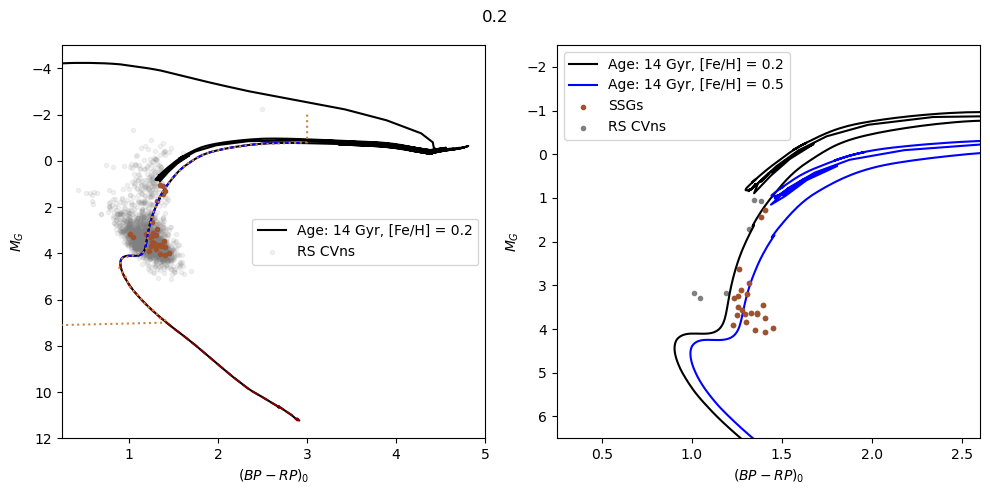

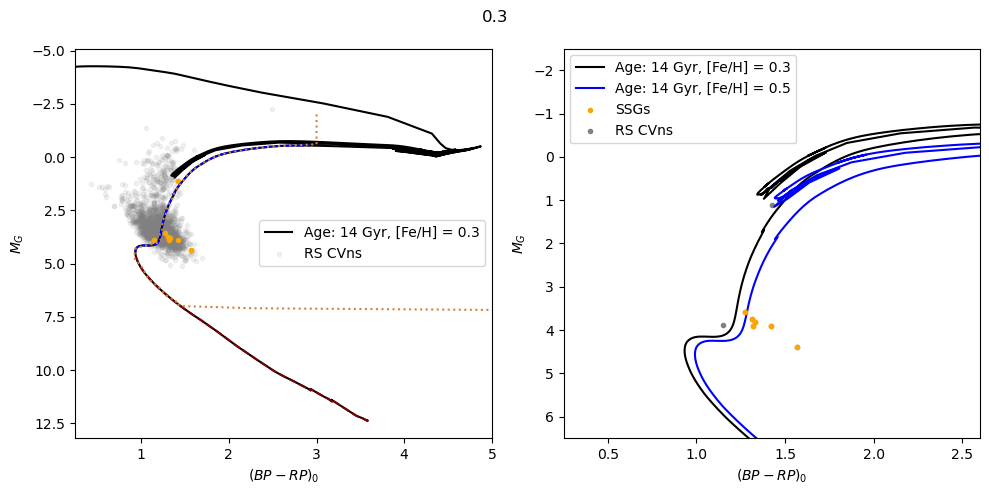

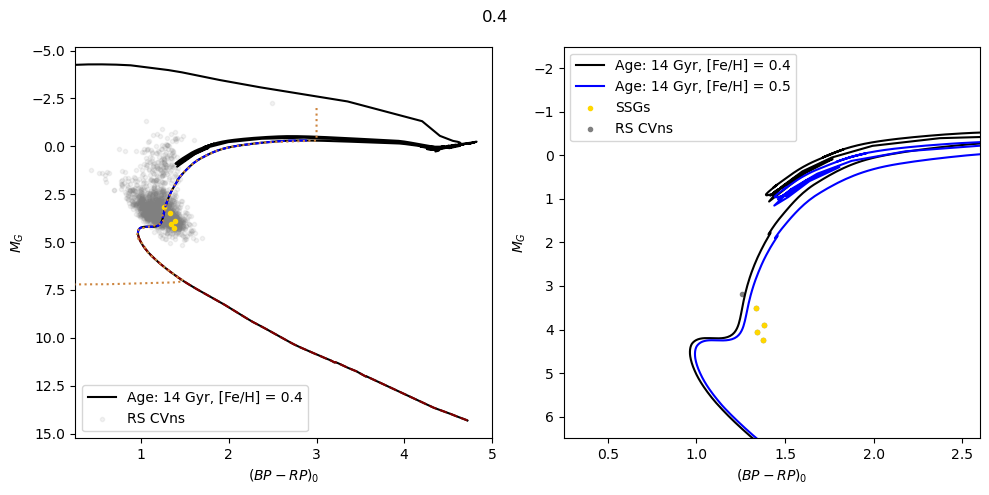

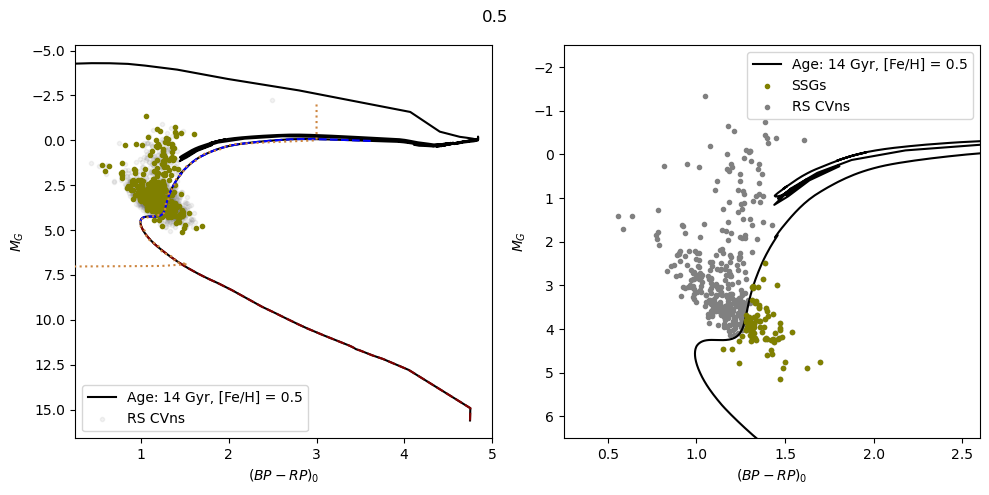

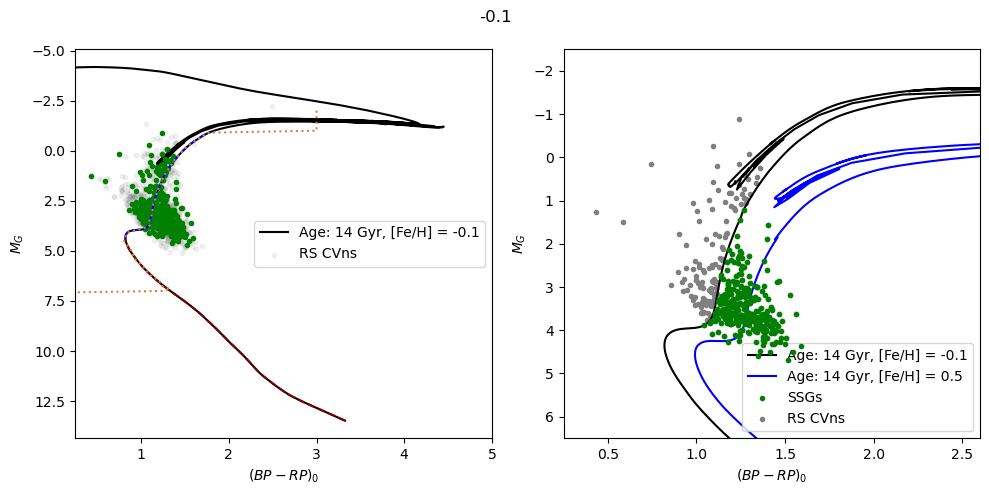

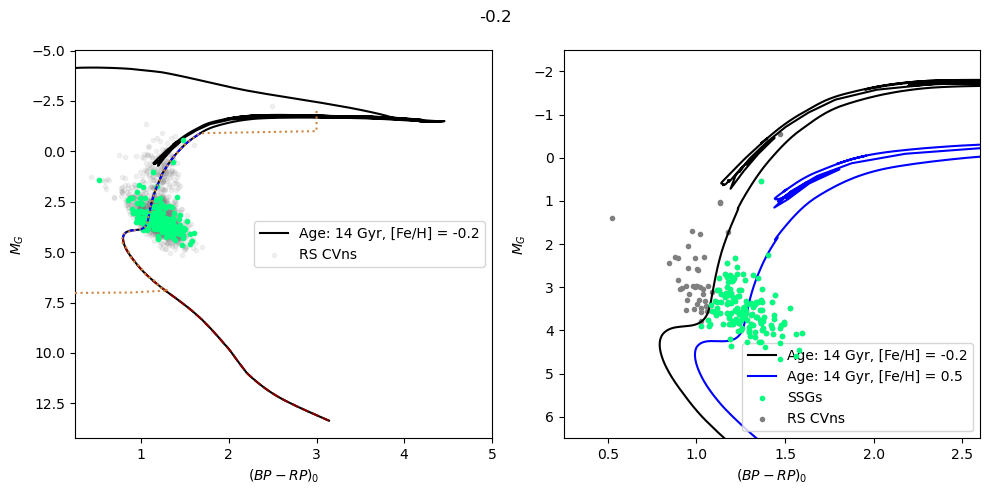

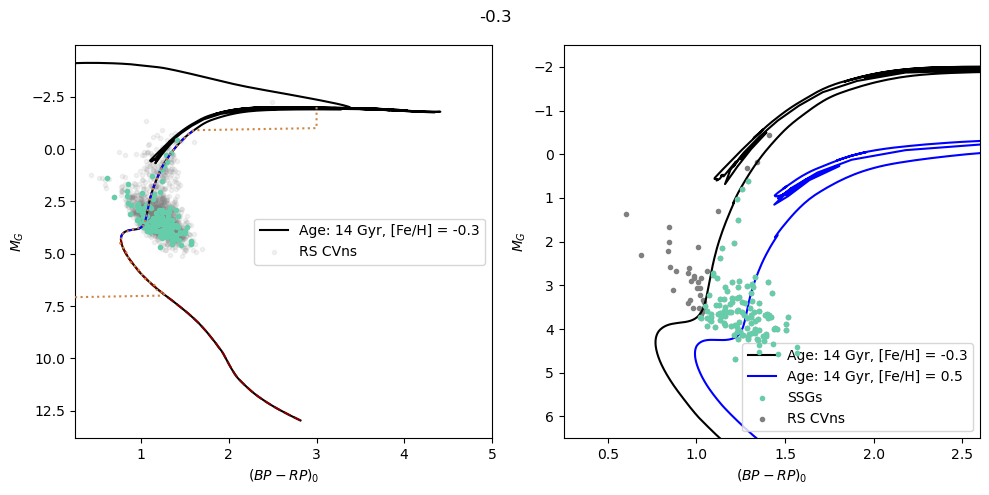

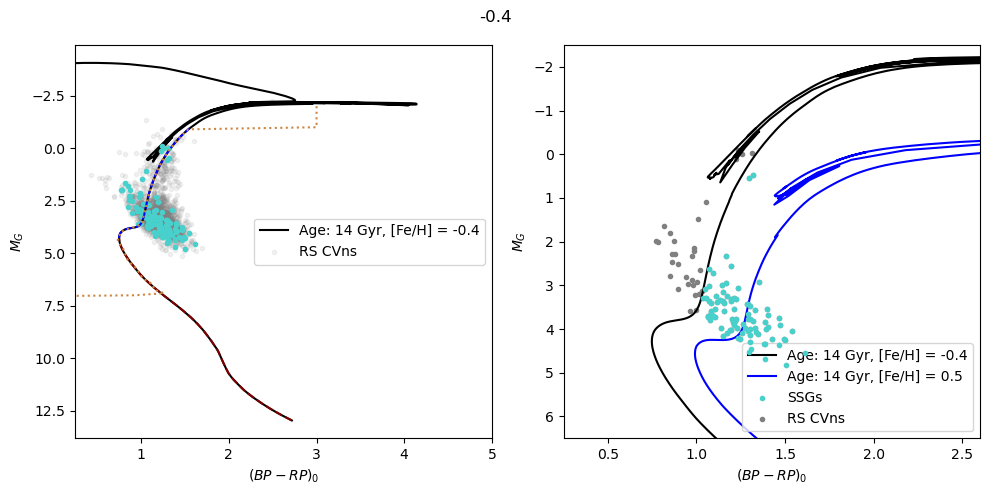

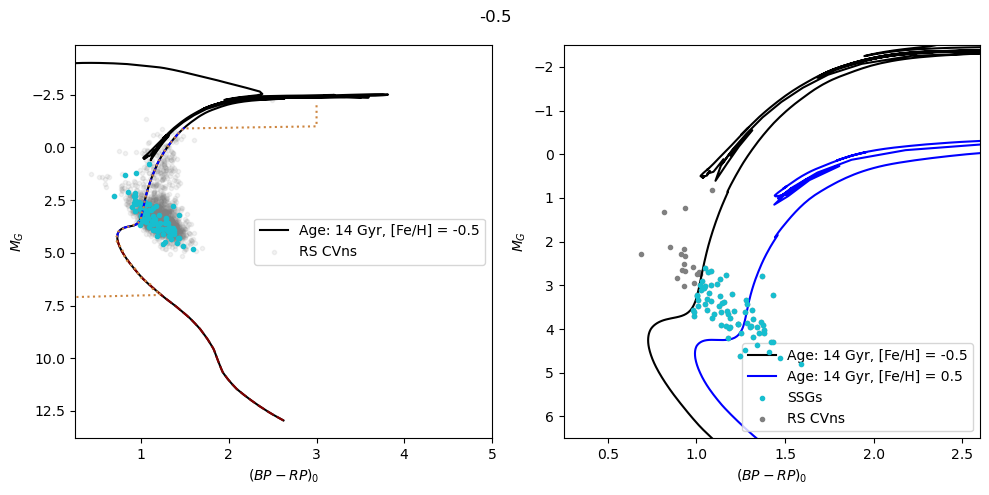

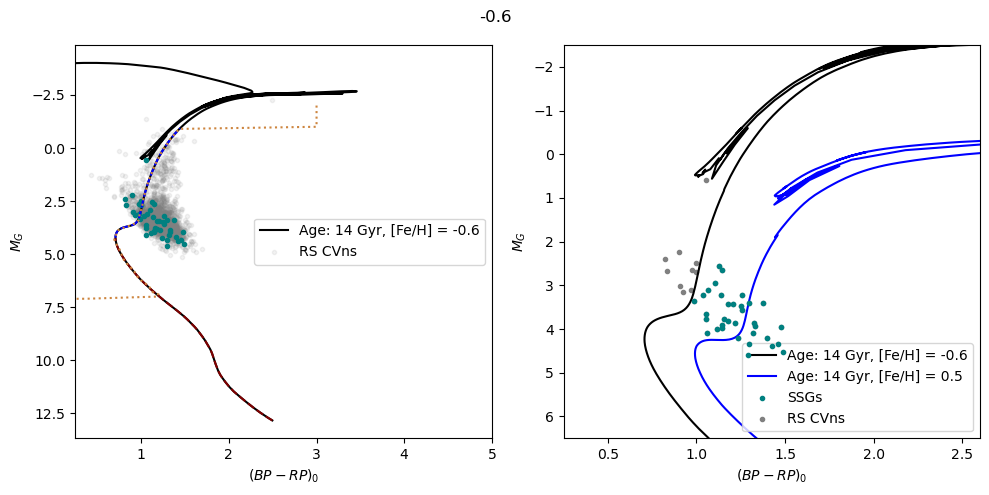

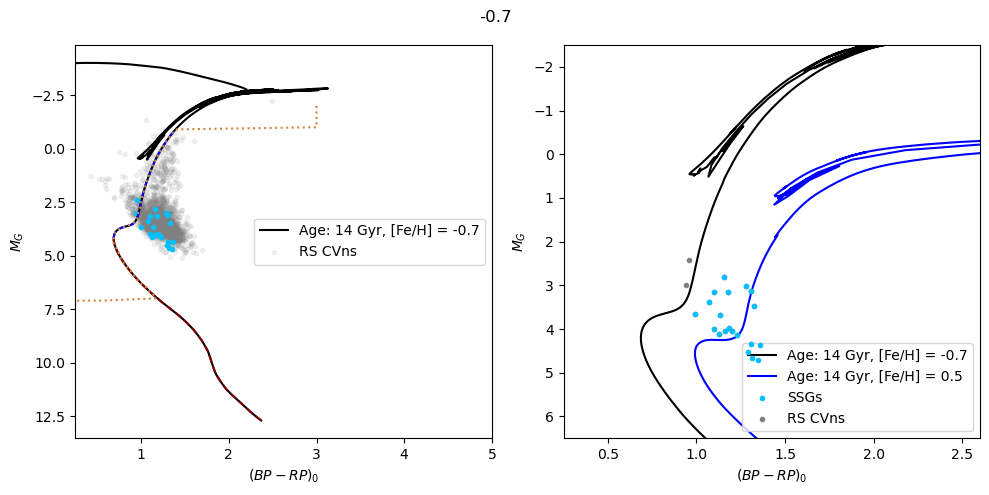

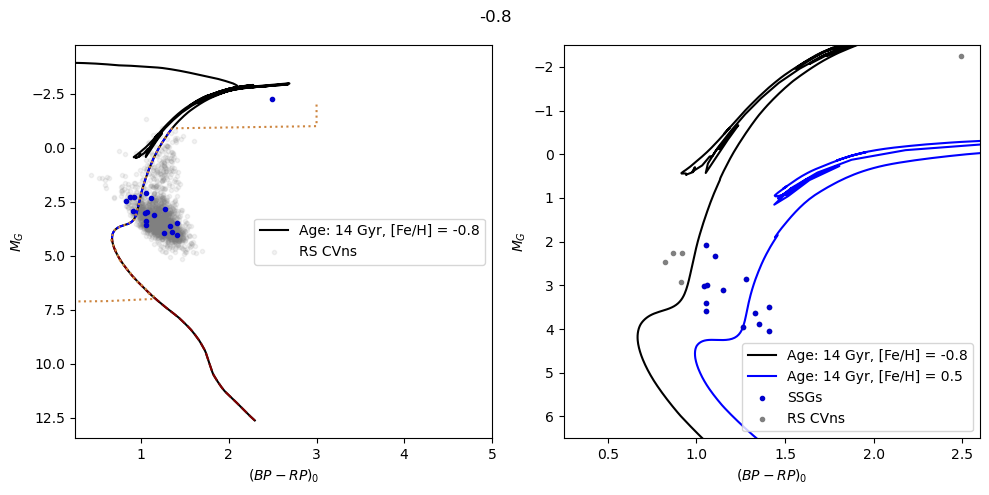

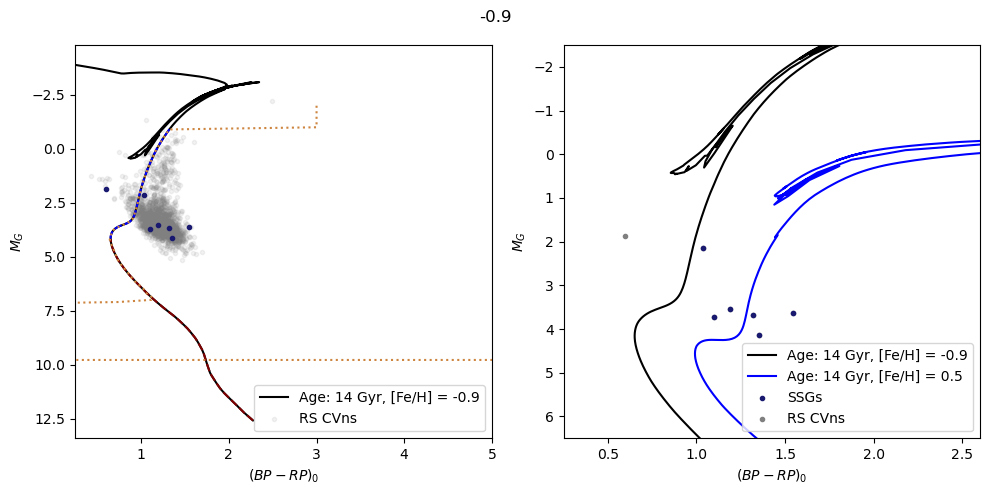

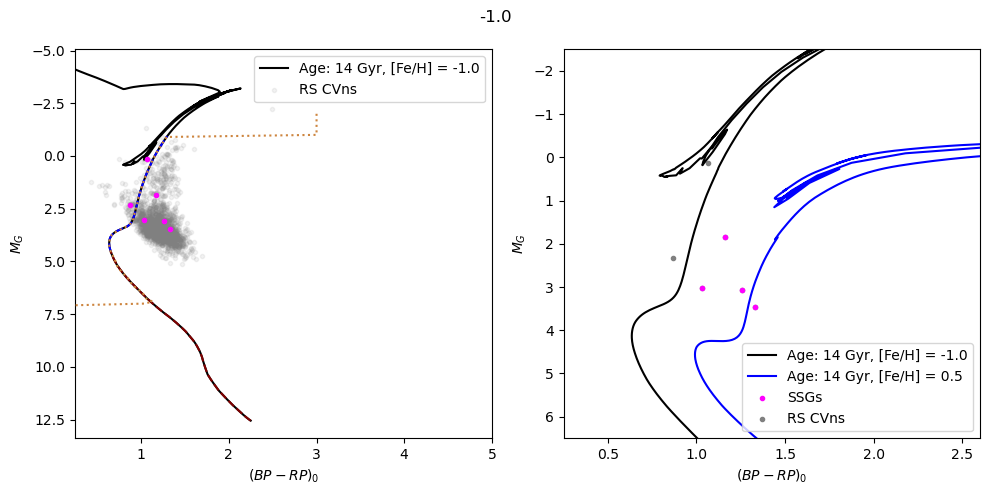

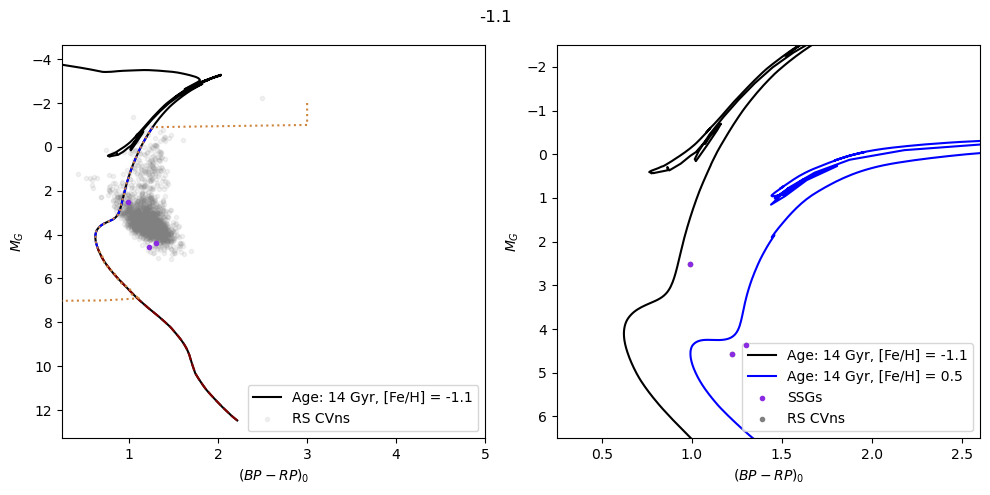

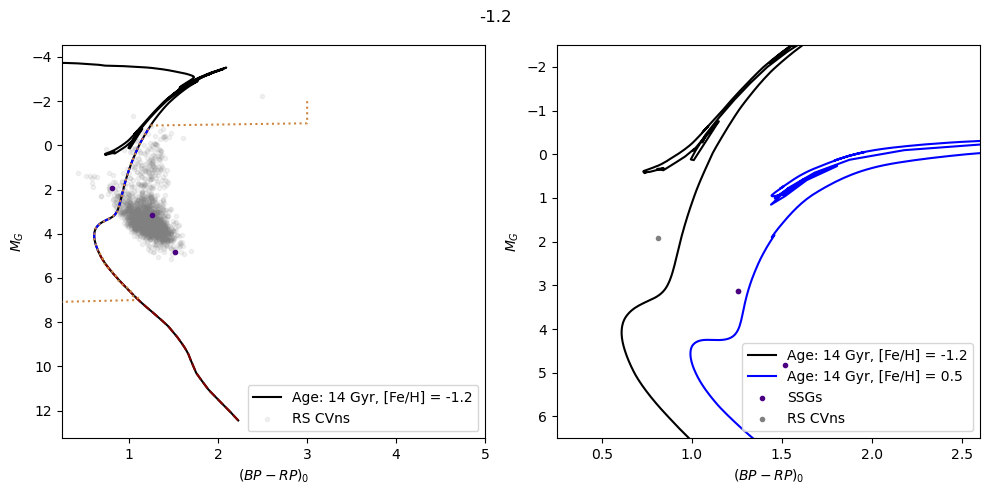

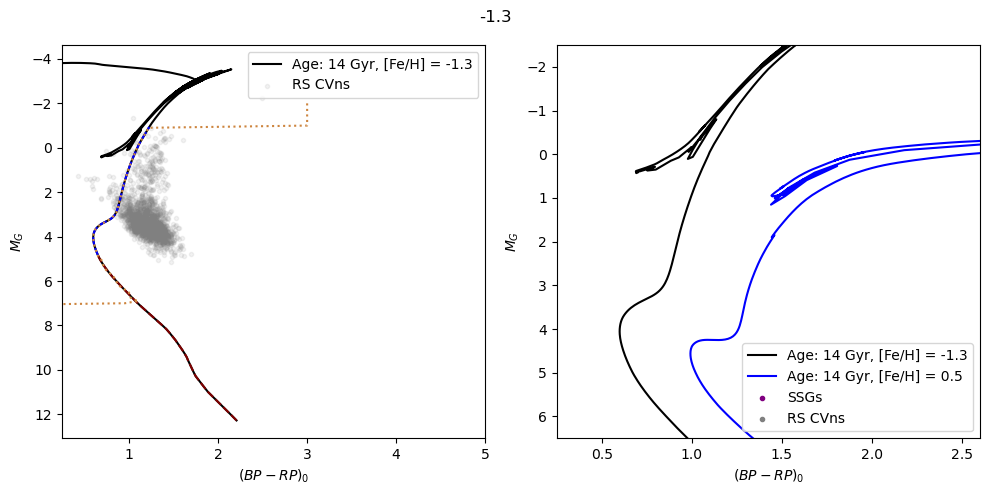

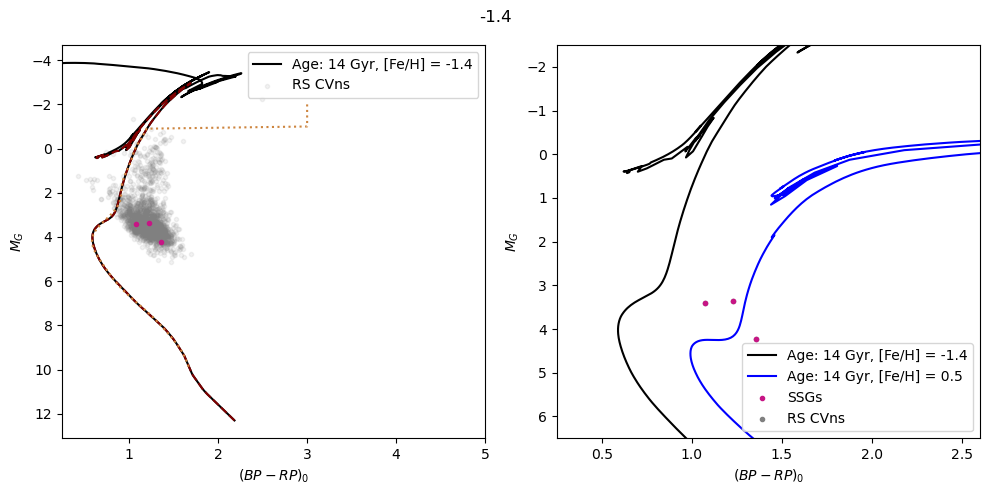

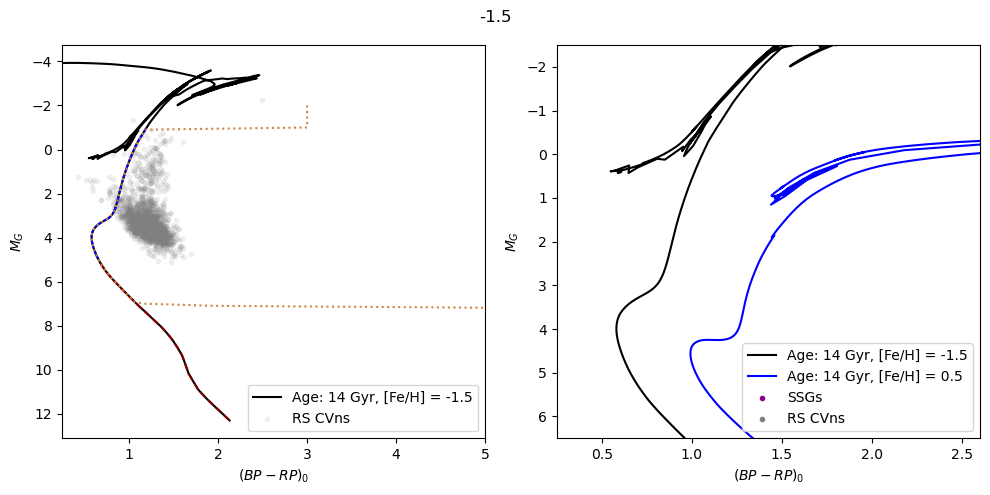

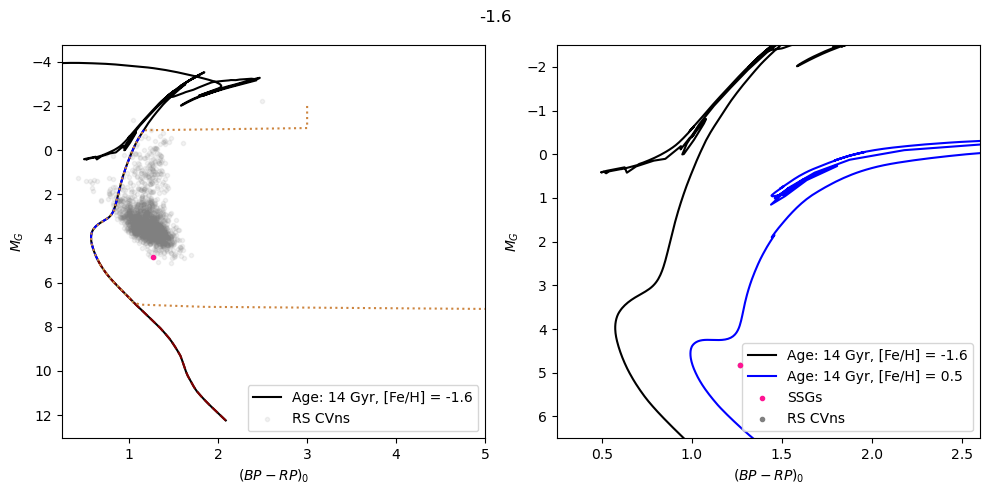

In [28]:
figure_path = 'Images/' #change to apporoprate path
valid_feh = (metallicity > -999)

ssgs = np.array(len(gaia_data)*['RS0'], dtype=str)
feh_bin = np.array(len(gaia_data)*['No [Fe/H]'])
g_test = np.arange(-2, 10, 0.1)

for i, item in enumerate(txtfiles):
    iso_file = r'files/isochrones/' + item
    color = colors[i]
    
    #Open isochrone
    iso_plot = ISOCMD(iso_file)
    
    giant = ((iso_plot.isocmds[0]['phase'] == 1) | (
        iso_plot.isocmds[0]['phase'] == 2))
    
    G = iso_plot.isocmds[0]['Gaia_G_EDR3']
    BP_RP = iso_plot.isocmds[0]['Gaia_BP_EDR3'] - iso_plot.isocmds[0]['Gaia_RP_EDR3']
    
    #change into negative
    feh_label = iso_file[37:-8]
    if feh_label[0:3] == 'low':
        feh = '-' + feh_label[4::]
    else:
        feh = feh_label
    feh = float(feh) #get metallicities
    
    
    #sort by metallicity
    
    if feh == 0.5:
        feh_mask = ((valid_feh == False) | (metallicity > 0.4))
        fit_lim = ((BP_RP >= 0.25) & (BP_RP <= 3.75) & (G >= -2.5) & (G < 7))
    else:
        feh_mask = ((metallicity <= feh) & (metallicity > feh-0.1))
        print(feh, feh-0.1)
    
        if feh >= 0:
            fit_lim = ((BP_RP >= 0.25) & (BP_RP <= 3) & (G >= -2.5) & (G < 7))
        elif feh == 0:
            fit_lim = ((BP_RP >= 0.25) & (BP_RP <= 0) & (G >= -2.5) & (G < 7))

        else:
            fit_lim = ((BP_RP >= 0.65)  & (G >= -1) & (G < 7))
    
    
    
    #fitting
    
    (min_feh,max_feh) = (np.where(BP_RP == np.min(BP_RP[fit_lim]))[0][0],
                 np.where(BP_RP == np.max(BP_RP[fit_lim]))[0][0])
    
    #conditons
    
    minG, maxG = G[min_feh], G[max_feh]
    
    
    
    if feh == -1.4:
        g_poly1 = np.polyfit(G[0:max_feh], BP_RP[0:max_feh], 20)
        p1 = np.poly1d(g_poly1)

        #bp_rp_test = np.arange(0.65, 2.60, 0.01)

        def p123(x): 
            condlist = [ (x >= maxG), (x < maxG)]
            functlist = [p1, 3]
            return np.piecewise(x, condlist, functlist)
    else:    
        g_poly1 = np.polyfit(G[min_feh:max_feh], BP_RP[min_feh:max_feh], 20)
        p1 = np.poly1d(g_poly1)
        g_poly2 = np.polyfit(G[fit_lim][0:max_feh], BP_RP[fit_lim][0:max_feh], 20)
        p2 = np.poly1d(g_poly2)


        def p123(x): 
            condlist = [ (x > minG), 
                    ((x <= minG) & (x > maxG)),
                   (x < maxG)]
            functlist = [p2, p1, 3]
            return np.piecewise(x, condlist, functlist)
        #del g_poly2, p2 #delete to save memory
    
    
    #SSG conditions
    
    ssg_con = (bp_rp > p123(M_G))
    
    #plotting
    fig, (ax, ax2) = plt.subplots(1,2, figsize=(10,5))
    
    fig.suptitle(feh)
    ax.plot(BP_RP, G, color = 'black', label=f'Age: 14 Gyr, [Fe/H] = {feh}')

    ax.plot(BP_RP[min_feh:max_feh], G[min_feh:max_feh], 
            color = 'blue', ls = '--', zorder=10)#label='Age: 14 Gyr, [Fe/H] = 0.5')
    ax.plot(BP_RP[0:min_feh], G[0:min_feh], 
            color = 'maroon', ls = '--', zorder=10)
    ax.plot(p123(g_test), g_test, color = 'peru', ls = ':', zorder=10)
    cm = ax.scatter(bp_rp, M_G, marker='.', 
            c = 'grey', label = 'RS CVns', zorder=-10, alpha=0.1)
    cm = ax.scatter(bp_rp[feh_mask], M_G[feh_mask], marker='.', 
                    c = color, zorder = 9)#c = metallicity[feh_mask], zorder=9, vmin=feh-0.1, vmax=feh)
    #cb = plt.colorbar(cm, ax=ax)
    ax.set_xlim(0.25,5)
    ax.invert_yaxis()
    ax.set_xlabel('$(BP-RP)_0$')
    ax.set_ylabel('$M_G$')
    ax.legend()
    
    ax2.plot(BP_RP, G, color = 'black', label=f'Age: 14 Gyr, [Fe/H] = {feh}')
    
    #plot second isochrone
    if feh != 0.5:
        ax2.plot(BP_RP05, G_05, color = 'blue', label = r'Age: 14 Gyr, [Fe/H] = 0.5')

    cm = ax2.scatter(bp_rp[feh_mask & ssg_con], M_G[feh_mask & ssg_con], marker='.', 
            c = color, label = 'SSGs', zorder=9)
    cm = ax2.scatter(bp_rp[feh_mask], M_G[feh_mask], marker='.', 
            c = 'grey', label = 'RS CVns',zorder=-10)
    
    ax2.set_xlim(0.25,2.60)
    ax2.set_ylim(-2.5,6.5)
    ax2.invert_yaxis()
    ax2.set_xlabel('$(BP-RP)_0$')
    ax2.set_ylabel('$M_G$')
    ax2.legend()
    fig.tight_layout()
    
    fig.savefig(figure_path + 'SSG_Isochrone_{feh_label}.png', dpi=300)
    
    #edit ssg list
    ssgs[feh_mask & ssg_con] = 'SSG'
    if feh == 0.5:
        feh_bin[feh_mask & valid_feh] = '[Fe/H] > 0.4'
    elif feh == 0.6:
        feh_bin[feh_mask & valid_feh] = '[Fe/H] <= -1.6'
    else:
        feh_bin[feh_mask & valid_feh] = f'{feh-0.1} < [Fe/H] <= {feh}'
    
    # delete variable to save memory
    del G, BP_RP, iso_plot, color, iso_file
    del feh_mask, ssg_con, feh, feh_label, fit_lim, min_feh, max_feh, minG, maxG 
    del p1, p123, g_poly1

In [29]:
ssgs[ssgs == 'RS0'] = 'RS'
original_ssg = (np.array(gaia_data['leiner_class']) == 'SSG') 
problema = (original_ssg & (ssgs == 'RS'))
print(gaia_data[problema]['source_id'])

    source_id     
------------------
904265992208905728


## Update Classifications

In [30]:
#Put CC CVn as cut
CCCVn = (gaia_data['star'] == 'CC CVn')
ssgs[CCCVn] = r'cut'

In [31]:
ssgs[CCCVn]

array(['cut'], dtype='<U3')

In [32]:
gaia_data['updated_class'] = ssgs

In [33]:
print(colors)
print(len(colors))

['red', 'salmon', 'sienna', 'orange', 'gold', 'olive', 'green', 'springgreen', 'mediumaquamarine', 'mediumturquoise', 'tab:cyan', 'teal', 'deepskyblue', 'mediumblue', 'midnightblue', 'magenta', 'blueviolet', 'indigo', 'purple', 'mediumvioletred', 'darkmagenta', 'deeppink']
22


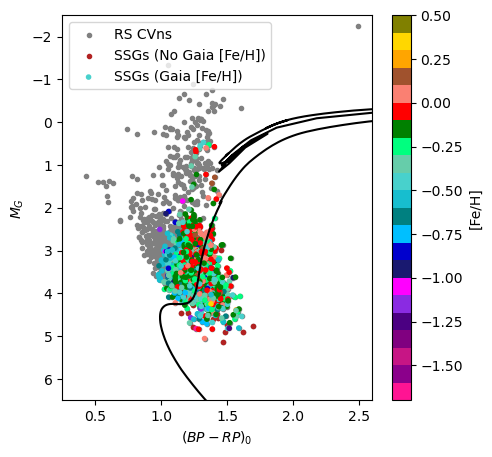

In [34]:
'''metallicity_bins = [0.0,0.1,0.2,0.3,0.4,0.5,-0.1,-0.2,-0.3,
                    -0.4,-0.5,-0.6,-0.7,-0.8,-0.9,-1.0,-1.1,
                    -1.2,-1.3,-1.4,-1.5, -1.6]
                    '''
col_index=np.array([5,4,3,2,1,0,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21])
color_map_col = np.array(colors)[np.flip(col_index)]

new_cmap = mplCol.ListedColormap(color_map_col)


#print(color_map_col)

fig, ax1 = plt.subplots(1, figsize=(5,5))
ax1.scatter(bp_rp, M_G, marker='.', 
            c = 'grey', label = 'RS CVns', zorder=-10)
ax1.scatter(bp_rp[(valid_feh==False) & (ssgs == 'SSG')], M_G[(valid_feh==False) & (ssgs == 'SSG')],
          color = 'firebrick', zorder=-10, 
           label = 'SSGs (No Gaia [Fe/H])', marker='.')

c_label = ax1.scatter(bp_rp[valid_feh & (ssgs == 'SSG')], M_G[valid_feh & (ssgs == 'SSG')], marker='.', 
            c = metallicity[valid_feh & (ssgs == 'SSG')], 
           label = 'SSGs (Gaia [Fe/H])', zorder=-10, 
           cmap=new_cmap, vmin=-1.7, vmax=0.5)

ax1.plot(BP_RP05, G_05, color = 'black')
cb = plt.colorbar(c_label, ax=ax1)
cb.set_label('[Fe/H]')
ax1.set_xlim(0.25,2.60)
ax1.set_ylim(-2.5,6.5)
ax1.invert_yaxis()
ax1.set_xlabel('$(BP-RP)_0$')
ax1.set_ylabel('$M_G$')


'''
for i, feh in enumerate(metallicity_bins):
    if feh == 0.5:
            feh_mask = ((valid_feh == False) | (metallicity > 0.4))
            feh_label = r'SSG $[Fe/H]\geq 0.4$'
    else:
        if feh == 1.6:
            feh_label = r'SSG $[Fe/H]\leq -1.6$'
        else:
            feh_label= f'SSG {feh-0.1} $< [Fe/H] \leq ${feh}'
        feh_mask = ((metallicity <= feh) & (metallicity > feh-0.1))
        
        #print(feh, feh_label)
        
    cm = ax.scatter(bp_rp[feh_mask & (ssgs == 'SSG')], M_G[feh_mask & (ssgs == 'SSG')], marker='.', 
                c = colors[i], label = feh_label, zorder=9)
 '''   
ax1.legend()
fig.savefig('CMDs\metallicitymap.png', dpi=300)

In [36]:
def frac(a,b):
    d = a/b * 100
    return round(d)

print('----------------------------- Full Sample ----------------------------------------------')
print('Original:', len(bp_rp[original_ssg]), 'or', str(frac(len(bp_rp[original_ssg]), len(bp_rp))) + '%')
print('Current:', len(bp_rp[ssgs == 'SSG']), 'or', str(frac(len(bp_rp[ssgs == 'SSG']), len(bp_rp))) + '%')
print('Total Size:', len(bp_rp))
print('----------------------------- With Valid [Fe/H] data ------------------------------------')
print('Original:', len(bp_rp[original_ssg]), 'or', str(frac(len(bp_rp[original_ssg]), len(bp_rp[valid_feh]))) + '%')
print('Current:', len(bp_rp[(ssgs == 'SSG') & valid_feh]), 'or', str(frac(len(bp_rp[(ssgs == 'SSG') & valid_feh]), len(bp_rp[valid_feh]))) + '%')
print('Total Size:', len(bp_rp[valid_feh]))


----------------------------- Full Sample ----------------------------------------------
Original: 448 or 24%
Current: 1165 or 61%
Total Size: 1895
----------------------------- With Valid [Fe/H] data ------------------------------------
Original: 448 or 30%
Current: 1079 or 72%
Total Size: 1494


# Save when confident

In [ ]:
gaia_df = gaia_data.to_pandas()
print(gaia_df.columns.to_list())


In [ ]:
#change name of columns
final_df = gaia_df.rename(columns={'source_id':'Gaia DR3 ID', 'mh_gspphot': 'fe_h',
                         'phot_g_mean_mag':'m_G', 'phot_g_mean_flux_over_error': 'Gaia G flux_over_error', 
                         'phot_bp_mean_mag': 'm_BP', 'phot_bp_mean_flux_over_error':'Gaia BP flux_over_error', 
                         'phot_rp_mean_mag': 'm_RP', 'phot_rp_mean_flux_over_error': 'Gaia RP flux_over_error'})

In [ ]:
print(final_df.columns.to_list())

In [ ]:
final_df['distance'] = distance

final_df = final_df[['star', '2MASS ID', 'Gaia DR3 ID', 'AllWISE ID', 'GALEX ID', 
                               'ra', 'dec', 'distance', 'vsini', 'VSX Period', 'Av', 'fe_h', 'm_G',
                               'Gaia G flux_over_error', 'm_BP', 'Gaia BP flux_over_error', 'm_RP', 
                               'Gaia RP flux_over_error', '2MASS J', '2MASS J error', '2MASS H', 
                               '2MASS H error', '2MASS K', '2MASS K error', 'WISE W1', 
                               'WISE W1 error', 'WISE W2', 'WISE W2 error', 'WISE W3', 'WISE W3 error',
                               'WISE W4', 'WISE W4 error', 'GALEX FUV', 'GALEX FUV Error', 'GALEX NUV',
                               'GALEX NUV Error', 'Li Profile', 'H-alpha Profile', 'Ca II H Profile', 
                               'Ca II K Profile', '2MASS_qph', 'ALLWISE_ccf', 'ALLWISE_qph', 
                               'leiner_class', 'updated_class']]
final_df

In [ ]:
final_df.to_csv(path + r'photometric_datav4.csv', index = False)